In [1]:
# Test R environment
x <- c(1, 2, 3, 4)
mean(x)

[1] 2.5

In [2]:
library('tidyverse')
matches <- readr::read_csv('https://raw.githubusercontent.com/rfordatascience/tidytuesday/master/data/2021/2021-11-30/matches.csv')

## inspect the data
str(matches)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.1     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Rows: 1237 Columns: 24
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (19): match_id, team1, team2, team1_away_or_home, team2_home_away, winne...
dbl  (5): score_team1, score_team2, wickets_team1, wickets_team2, margin

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


spc_tbl_ [1,237 × 24] (S3: spec_tbl_df/tbl_df/tbl/data.frame)
 $ match_id            : chr [1:1237] "ODI # 1028" "ODI # 1029" "ODI # 1030" "ODI # 1031" ...
 $ team1               : chr [1:1237] "West Indies" "West Indies" "Sri Lanka" "West Indies" ...
 $ team2               : chr [1:1237] "Australia" "Sri Lanka" "West Indies" "Australia" ...
 $ score_team1         : num [1:1237] 172 194 102 231 213 211 262 266 198 202 ...
 $ score_team2         : num [1:1237] 173 124 104 217 214 205 265 183 199 186 ...
 $ wickets_team1       : num [1:1237] 9 10 10 10 5 8 8 6 8 10 ...
 $ wickets_team2       : num [1:1237] 9 10 3 10 7 10 5 9 7 9 ...
 $ team1_away_or_home  : chr [1:1237] "away" "away" "away" "away" ...
 $ team2_home_away     : chr [1:1237] "home" "away" "away" "home" ...
 $ winner              : chr [1:1237] "Australia" "West Indies" "West Indies" "West Indies" ...
 $ margin              : num [1:1237] 1 70 7 14 3 6 5 83 3 16 ...
 $ margin_type         : chr [1:1237] "wicket" "runs" "wick

In [3]:
## preview the data
view(matches)

In [5]:
## MOST COMMON DPLYR FUNCTIONS
## select(): subset columns. To select all columns except certain ones, put a “-” in front of the variable to exclude it.
## filter(): subset rows on conditions
## mutate(): create new columns by using information from other columns
## group_by() and summarize(): create summary statistics on grouped data
## arrange(): sort results
## count(): count discrete values

## select(matches, winner, ground_country, match_date)
## filter(matches, winner == 'India')

## Combining above two statements
## select(filter(matches, winner == 'India'), winner, ground_country, match_date)
## or using pipe
## filter(matches, winner == 'India') %>% select(winner, ground_country, match_date)

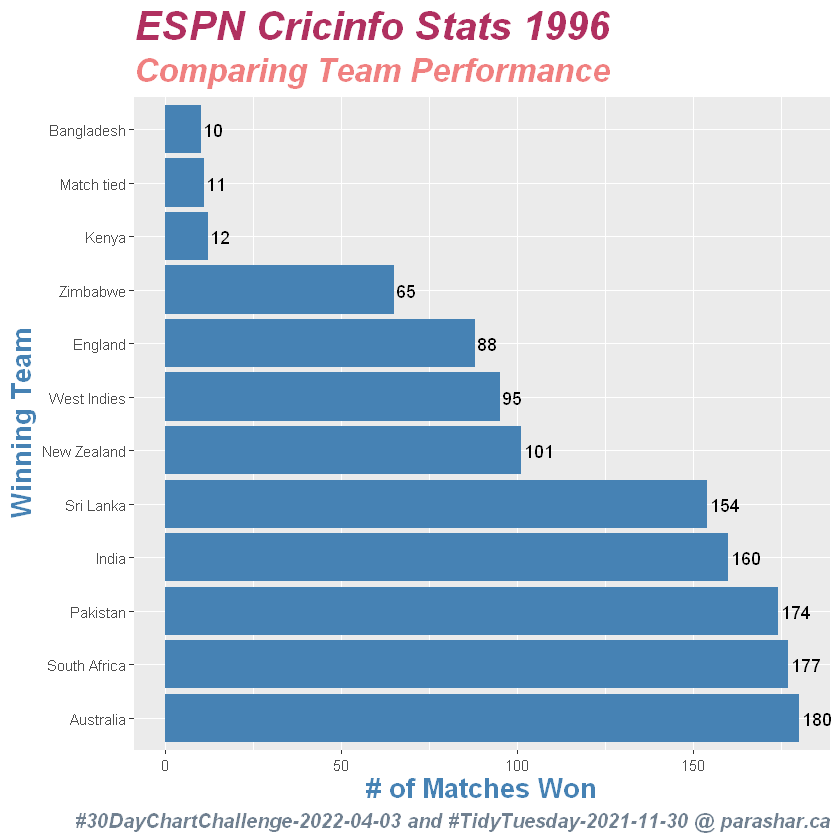

In [4]:
select(matches, winner, ground_country, match_date) %>%
 group_by(winner) %>%
  summarize(wins = n()) %>% 
    filter(wins>1) %>%
    filter(winner != 'No result') %>%
    arrange(desc(wins)) %>% 
ggplot(aes(y=reorder(winner, -wins), x=wins)) + 
    geom_bar(stat="identity", fill="steelblue") +
    geom_text(aes(label = wins), hjust = -0.1) +
labs(
    title = 'ESPN Cricinfo Stats 1996',
    subtitle = 'Comparing Team Performance', 
    x = '# of Matches Won', 
    y = 'Winning Team',
    caption = '#30DayChartChallenge-2022-04-03 and #TidyTuesday-2021-11-30 @ parashar.ca'
) + 
theme(
    plot.title = element_text(color="maroon", size=24, face="bold.italic"),
    plot.subtitle = element_text(color="lightcoral", size=20, face="bold.italic"),
    axis.title.x = element_text(color="steelblue", size=16, face="bold"),
    axis.title.y = element_text(color="steelblue", size=16, face="bold"),
    plot.caption = element_text(color="slategrey", size=12, face="bold.italic")
)

In [6]:
# ggsave("C:/../2022-04-03.jpg")